<a href="https://www.kaggle.com/code/zionqassim/pneumonia-detection?scriptVersionId=333437473" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Pneumonia Detection from Chest X-Ray Images
## Graduation Project Notebook: Custom CNN vs MobileNetV2 vs DenseNet121

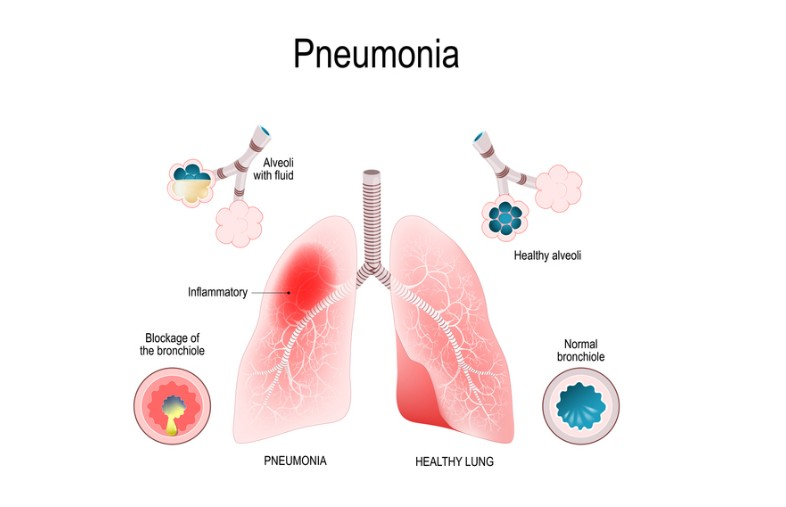

### Project idea
This project builds a complete deep learning pipeline for detecting pneumonia from chest X-ray images.
Instead of training only one model, we compare three different architectures:

1. **Custom CNN** — a model built from scratch.
2. **MobileNetV2** — a lightweight transfer learning model.
3. **DenseNet121** — a stronger transfer learning model commonly used in medical image analysis.

### Important note
This notebook is for **educational and research purposes only**. It is not a medical diagnosis system.

## 1. Import Libraries

**What we do in this cell:**

We import the libraries needed for:
- Reading files and folders.
- Preparing image datasets.
- Building deep learning models.
- Evaluating predictions using accuracy, precision, recall, F1-score, and confusion matrix.
- Drawing clean figures for the report/poster.

**Why this is important:**

A graduation project should not only train a model. It should also include proper data analysis, evaluation, visualization, and final comparison.

In [1]:
# os is used to work with folders and file paths.
import os

# json is used to save class names and final results for the web application.
import json

# random is used to control random operations and make the notebook reproducible.
import random

# pathlib gives cleaner path handling than raw strings.
from pathlib import Path

# numpy is used for numerical operations.
import numpy as np

# pandas is used to create clean result tables.
import pandas as pd

# matplotlib is used to draw all plots in a professional and controllable way.
import matplotlib.pyplot as plt

# TensorFlow and Keras are used to build and train deep learning models.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2, DenseNet121
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

# sklearn is used for splitting the dataset and calculating evaluation metrics.
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# PIL is used to open and display images for visual inspection.
from PIL import Image

# This makes plots appear directly inside the notebook.
%matplotlib inline

print("TensorFlow version:", tf.__version__)

2026-07-07 15:40:36.847661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783438836.869687     108 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783438836.876886     108 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783438836.894167     108 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783438836.894186     108 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783438836.894189     108 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


## 2. Reproducibility Settings

**What we do in this cell:**

We set random seeds for Python, NumPy, and TensorFlow.

**Why this is important:**

Deep learning contains randomness: image shuffling, weight initialization, and augmentation. Setting seeds helps make the results more stable when the notebook is rerun.

In [2]:
# This seed value is used everywhere to reduce randomness.
SEED = 42

# Set Python random seed.
random.seed(SEED)

# Set NumPy random seed.
np.random.seed(SEED)

# Set TensorFlow random seed.
tf.random.set_seed(SEED)

print("Reproducibility seed:", SEED)

Reproducibility seed: 42


## 3. Project Configuration

**What we do in this cell:**

We define the main project settings:
- Image size.
- Batch size.
- Number of epochs.
- Validation split.
- Output folder.

**Why this is important:**

Keeping all settings in one place makes the notebook easier to understand and easier to modify.

In [3]:
# Image size used by all three models.
# 150x150 keeps training faster and follows the style of the original CNN notebook.
IMG_SIZE = (150, 150)

# Input shape expected by Keras models: height, width, channels.
INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3)

# Batch size controls how many images are processed at once.
BATCH_SIZE = 32

# Number of epochs. For a final run, 12 is a reasonable starting point.
EPOCHS = 12

# Validation size created from the training data.
# We do this because the original Kaggle validation folder is very small.
VALIDATION_SIZE = 0.15

# Threshold for binary classification.
# Probability >= 0.5 means Pneumonia, otherwise Normal.
THRESHOLD = 0.50

# Output folder where models, tables, and app files are saved.
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Output folder:", OUTPUT_DIR)

Image size: (150, 150)
Batch size: 32
Epochs: 12
Output folder: /kaggle/working


## 4. Automatic Dataset Path Detection

**What we do in this cell:**

We automatically search inside `/kaggle/input` for the correct dataset folder.

The notebook looks for a folder that contains:

```text
train/
test/
val/      optional
```

and inside `train/` it expects:

```text
NORMAL/
PNEUMONIA/
```

**Why this is important:**

Kaggle dataset paths can be different depending on the dataset slug and folder nesting. This cell avoids the `FileNotFoundError` problem.

In [4]:
def list_first_input_folders(root="/kaggle/input", max_items=40):
    """Print the first folders inside Kaggle input to help debugging if the dataset is not found."""
    root_path = Path(root)
    if not root_path.exists():
        print(f"Input root does not exist: {root}")
        return

    print("Available folders inside Kaggle input:")
    count = 0
    for path in root_path.rglob("*"):
        if path.is_dir():
            print("-", path)
            count += 1
            if count >= max_items:
                break


def has_required_class_folders(train_dir):
    """Check whether the train folder contains NORMAL and PNEUMONIA class folders."""
    train_path = Path(train_dir)
    if not train_path.exists():
        return False

    class_folders = {p.name.upper() for p in train_path.iterdir() if p.is_dir()}
    return {"NORMAL", "PNEUMONIA"}.issubset(class_folders)


def find_chest_xray_dataset(input_root="/kaggle/input"):
    """Find the real dataset directory even when Kaggle uses nested folders."""
    input_root = Path(input_root)

    if not input_root.exists():
        raise FileNotFoundError(f"Kaggle input folder was not found: {input_root}")

    candidates = []

    # Walk through all folders and search for train/test folders.
    for current_dir, dirnames, filenames in os.walk(input_root):
        current_path = Path(current_dir)
        lower_to_real = {name.lower(): name for name in dirnames}

        # A valid dataset folder must contain train and test.
        if "train" in lower_to_real and "test" in lower_to_real:
            train_dir = current_path / lower_to_real["train"]
            test_dir = current_path / lower_to_real["test"]

            # The train folder must contain NORMAL and PNEUMONIA.
            if has_required_class_folders(train_dir):
                candidates.append(current_path)

    if not candidates:
        list_first_input_folders(input_root)
        raise FileNotFoundError(
            "Could not find a chest X-ray dataset folder containing train/test and NORMAL/PNEUMONIA classes. "
            "Please check that the Kaggle dataset is attached to the notebook."
        )

    # Prefer the candidate that also has a validation folder.
    candidates = sorted(
        candidates,
        key=lambda p: (not (p / "val").exists(), len(str(p)))
    )

    return candidates[0]


# Keep this as None for automatic detection.
# If you ever need a manual path, write it here as a string.
MANUAL_DATA_DIR = None

# Detect dataset path automatically.
DATA_DIR = Path(MANUAL_DATA_DIR) if MANUAL_DATA_DIR else find_chest_xray_dataset("/kaggle/input")

# Define final train, validation, and test paths.
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

print("Dataset path found:", DATA_DIR)
print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR, "| exists:", VAL_DIR.exists())
print("Test path:", TEST_DIR)
print("Train folders:", sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()]))

Dataset path found: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Train path: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
Validation path: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val | exists: True
Test path: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test
Train folders: ['NORMAL', 'PNEUMONIA']


## 5. Load Image Paths and Labels

**What we do in this cell:**

We collect all image paths and convert class names into numeric labels:

- `NORMAL` → 0
- `PNEUMONIA` → 1

**Why this is important:**

Models do not understand text labels directly. They need numeric labels during training.

In [5]:
# These are the allowed image formats.
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

# Fixed class order is important for correct interpretation of predictions.
class_names = ["NORMAL", "PNEUMONIA"]
class_to_label = {class_name: index for index, class_name in enumerate(class_names)}
label_to_class = {index: class_name for class_name, index in class_to_label.items()}


def collect_image_paths_and_labels(split_dir):
    """Collect image file paths and labels from a split folder."""
    image_paths = []
    labels = []

    split_dir = Path(split_dir)
    if not split_dir.exists():
        return image_paths, labels

    for class_name in class_names:
        class_dir = split_dir / class_name
        if not class_dir.exists():
            continue

        for image_path in class_dir.rglob("*"):
            if image_path.suffix.lower() in IMAGE_EXTENSIONS:
                image_paths.append(str(image_path))
                labels.append(class_to_label[class_name])

    return image_paths, labels


# Load paths from the original Kaggle folders.
train_paths_original, train_labels_original = collect_image_paths_and_labels(TRAIN_DIR)
val_paths_original, val_labels_original = collect_image_paths_and_labels(VAL_DIR)
test_paths, test_labels = collect_image_paths_and_labels(TEST_DIR)

# Merge original train and val, then create a stronger validation split.
# The official validation folder in this dataset is very small, so this gives more stable validation curves.
all_train_paths = train_paths_original + val_paths_original
all_train_labels = train_labels_original + val_labels_original

# Create a stratified train/validation split so both classes are represented in both splits.
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_paths,
    all_train_labels,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=all_train_labels
)

print("Class mapping:", class_to_label)
print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Training images: 4447
Validation images: 785
Test images: 624


## 6. Dataset Distribution Table

**What we do in this cell:**

We count how many `NORMAL` and `PNEUMONIA` images exist in each split.

**Why this is important:**

Medical datasets are often imbalanced. If one class has many more images, accuracy alone can be misleading.

In [6]:
def count_labels(labels):
    """Count labels and return a dictionary with class names."""
    labels = np.array(labels)
    return {class_name: int(np.sum(labels == class_to_label[class_name])) for class_name in class_names}

# Create a clean table for the report.
distribution_df = pd.DataFrame({
    "Train": count_labels(train_labels),
    "Validation": count_labels(val_labels),
    "Test": count_labels(test_labels)
}).T

# Add total column for easier reading.
distribution_df["Total"] = distribution_df.sum(axis=1)

# Display the distribution table.
distribution_df

,NORMAL,PNEUMONIA,Total
Train,1147,3300,4447
Validation,202,583,785
Test,234,390,624


## 7. Visualize Class Distribution

**What we do in this cell:**

We draw a clean class distribution chart.

**Why this is important:**

This plot helps the reader quickly understand whether the dataset is balanced or imbalanced.

<Figure size 1000x600 with 0 Axes>

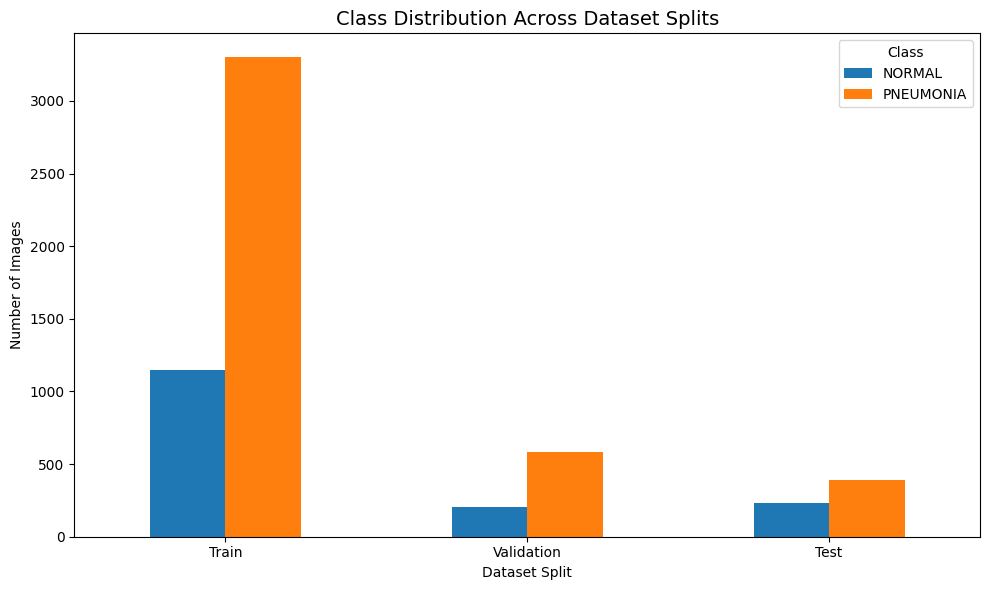

In [7]:
# Create a professional figure.
plt.figure(figsize=(10, 6))

# Draw the bar chart using pandas and matplotlib.
distribution_df[class_names].plot(kind="bar", figsize=(10, 6), rot=0)

# Add title and axis labels.
plt.title("Class Distribution Across Dataset Splits", fontsize=14)
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

# Add a legend for class names.
plt.legend(title="Class")

# Improve layout spacing.
plt.tight_layout()
plt.show()

## 8. Preview Sample X-Ray Images

**What we do in this cell:**

We display small sample X-ray images from both classes.

**Why this is important:**

Before training a model, we should visually inspect the data to understand what the model will learn from.

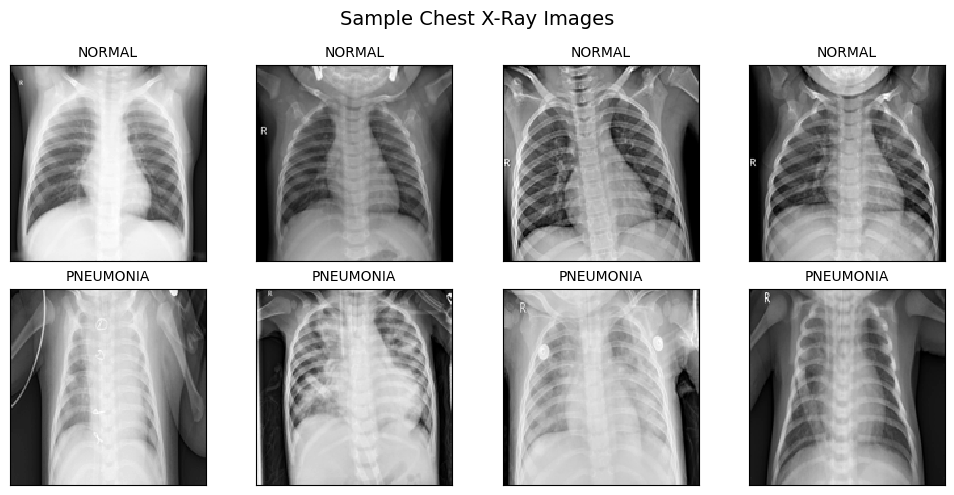

In [8]:
def plot_sample_images(image_paths, labels, samples_per_class=4):
    """Display a small grid of sample images for each class."""
    plt.figure(figsize=(10, 5))
    plot_index = 1

    for class_name in class_names:
        class_label = class_to_label[class_name]
        class_indices = [i for i, label in enumerate(labels) if label == class_label]
        selected_indices = random.sample(class_indices, min(samples_per_class, len(class_indices)))

        for index in selected_indices:
            image = Image.open(image_paths[index]).convert("L").resize(IMG_SIZE)
            plt.subplot(len(class_names), samples_per_class, plot_index)
            plt.imshow(image, cmap="gray", interpolation="none")
            plt.title(class_name, fontsize=10)
            plt.xticks([])
            plt.yticks([])
            plot_index += 1

    plt.suptitle("Sample Chest X-Ray Images", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_sample_images(train_paths, train_labels, samples_per_class=4)

## 9. TensorFlow Dataset Pipeline

**What we do in this cell:**

We create a reusable TensorFlow pipeline that:
- Reads an image from disk.
- Decodes it.
- Resizes it to `150 x 150`.
- Converts it to RGB.
- Batches and prefetches the data.

**Why this is important:**

A clean data pipeline makes training faster and keeps the code organized.

In [9]:
# AUTOTUNE lets TensorFlow choose efficient loading settings automatically.
AUTOTUNE = tf.data.AUTOTUNE


def load_image(image_path, label):
    """Read one image file and return the image tensor with its label."""
    # Read image bytes from disk.
    image = tf.io.read_file(image_path)

    # Decode image and force 3 channels because pretrained models expect RGB input.
    image = tf.image.decode_image(image, channels=3, expand_animations=False)

    # Resize all images to the same size.
    image = tf.image.resize(image, IMG_SIZE)

    # Convert image values to float32.
    image = tf.cast(image, tf.float32)

    # Set a fixed shape so Keras receives images with known dimensions.
    image.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])

    # Convert label to float because binary classification uses a sigmoid output.
    label = tf.cast(label, tf.float32)

    return image, label


def create_dataset(image_paths, labels, shuffle=False):
    """Create a batched TensorFlow dataset from image paths and labels."""
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths), seed=SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


# Create datasets for training, validation, and testing.
train_ds = create_dataset(train_paths, train_labels, shuffle=True)
val_ds = create_dataset(val_paths, val_labels, shuffle=False)
test_ds = create_dataset(test_paths, test_labels, shuffle=False)

print("TensorFlow datasets created successfully.")

I0000 00:00:1783438881.297373     108 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783438881.303425     108 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


TensorFlow datasets created successfully.


## 10. Class Weights

**What we do in this cell:**

We calculate class weights to reduce the effect of class imbalance.

**Why this is important:**

If the dataset contains more pneumonia images than normal images, the model may become biased toward predicting pneumonia. Class weights help the model pay more attention to the minority class.

In [10]:
# Compute class weights from the training labels.
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=np.array(train_labels)
)

# Convert the weights into the format expected by Keras.
class_weight_dict = {0: float(weights[0]), 1: float(weights[1])}

print("Class weights:", class_weight_dict)

Class weights: {0: 1.9385353095030515, 1: 0.6737878787878788}


## 11. Shared Data Augmentation Layer

**What we do in this cell:**

We create one augmentation block used by all models.

**Why this is important:**

Augmentation creates slightly modified versions of training images. This helps the model generalize better and reduces overfitting.

In [11]:
# Data augmentation is applied only during training.
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

print("Data augmentation layer is ready.")

Data augmentation layer is ready.


## 12. Plotting Functions

**What we do in this cell:**

We define reusable plotting functions for:
- Training accuracy and validation accuracy.
- Training loss and validation loss.
- Confusion matrix.
- Incorrect predictions.

**Why this is important:**

Good plots make the notebook look more professional and make the results easier to explain in a presentation.

In [12]:
def plot_training_history(history, model_name):
    """Plot training curves using a clean style similar to the original CNN notebook."""
    epochs = range(len(history.history["accuracy"]))

    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(20, 8)

    ax[0].plot(epochs, train_acc, "go-", label="Training Accuracy")
    ax[0].plot(epochs, val_acc, "ro-", label="Validation Accuracy")
    ax[0].set_title(f"{model_name}: Training & Validation Accuracy", fontsize=14)
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(epochs, train_loss, "g-o", label="Training Loss")
    ax[1].plot(epochs, val_loss, "r-o", label="Validation Loss")
    ax[1].set_title(f"{model_name}: Training & Validation Loss", fontsize=14)
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, model_name):
    """Plot a readable confusion matrix."""
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{model_name}: Confusion Matrix", fontsize=14)
    plt.xticks(np.arange(len(class_names)), class_names, rotation=30)
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

    plt.colorbar()
    plt.tight_layout()
    plt.show()


def plot_incorrect_predictions(image_paths, y_true, y_pred, max_images=6):
    """Display incorrect predictions as small images like the original notebook."""
    incorrect = np.where(np.array(y_true) != np.array(y_pred))[0]

    if len(incorrect) == 0:
        print("No incorrect predictions found.")
        return

    selected = incorrect[:max_images]

    plt.figure(figsize=(8, 9))
    i = 0
    for index in selected:
        image = Image.open(image_paths[index]).convert("L").resize(IMG_SIZE)
        plt.subplot(3, 2, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(image, cmap="gray", interpolation="none")
        plt.title(
            "Predicted: {}\nActual: {}".format(
                label_to_class[int(y_pred[index])],
                label_to_class[int(y_true[index])]
            ),
            fontsize=9
        )
        i += 1

    plt.suptitle("Incorrect Predictions", fontsize=14)
    plt.tight_layout()
    plt.show()

## 13. Model 1 — Custom CNN

**What we do in this cell:**

We build a CNN from scratch using convolution, pooling, dropout, and dense layers.

**Why this model is useful:**

The custom CNN is our baseline. It shows what we can achieve without transfer learning.

In [13]:
def build_custom_cnn():
    """Build a custom CNN model from scratch."""
    inputs = keras.Input(shape=INPUT_SHAPE, name="input_image")

    # Normalize images from [0, 255] to [0, 1].
    x = layers.Rescaling(1.0 / 255, name="rescaling")(inputs)

    # Apply augmentation only during training.
    x = data_augmentation(x)

    # First convolution block.
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Second convolution block.
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Third convolution block.
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same", name="last_conv_layer")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Convert feature maps into a compact vector.
    x = layers.GlobalAveragePooling2D()(x)

    # Dropout reduces overfitting.
    x = layers.Dropout(0.35)(x)

    # Dense layer learns final decision patterns.
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.25)(x)

    # Sigmoid output is used for binary classification.
    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(inputs, outputs, name="Custom_CNN")
    return model


custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

## 14. Transfer Learning Helper

**What we do in this cell:**

We create a helper function to build MobileNetV2 and DenseNet121 models.

**Why this is important:**

Transfer learning uses knowledge learned from large image datasets. This usually improves performance when our medical dataset is limited.

In [14]:
def build_transfer_model(model_name, base_class, preprocess_function):
    """Build a transfer learning model using a pretrained CNN backbone."""
    try:
        # Try to load ImageNet weights.
        base_model = base_class(
            include_top=False,
            weights="imagenet",
            input_shape=INPUT_SHAPE
        )
        used_pretrained = True
        print(f"{model_name}: ImageNet weights loaded successfully.")

    except Exception as error:
        # If Kaggle internet is off and weights are unavailable, continue without crashing.
        print(f"{model_name}: Could not load ImageNet weights.")
        print("Reason:", error)
        print("The model will use random weights instead. For better final results, enable Internet in Kaggle settings.")
        base_model = base_class(
            include_top=False,
            weights=None,
            input_shape=INPUT_SHAPE
        )
        used_pretrained = False

    # Freeze pretrained backbone if ImageNet weights are available.
    # If weights are random, allow training because freezing random weights is not useful.
    base_model.trainable = not used_pretrained

    inputs = keras.Input(shape=INPUT_SHAPE, name="input_image")

    # Apply augmentation to improve generalization.
    x = data_augmentation(inputs)

    # Use the correct preprocessing function for the selected backbone.
    x = preprocess_function(x)

    # Extract high-level image features using the base model.
    x = base_model(x, training=False)

    # Pool feature maps into a compact vector.
    x = layers.GlobalAveragePooling2D()(x)

    # Dropout helps reduce overfitting.
    x = layers.Dropout(0.35)(x)

    # A small dense head learns the final binary classification.
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.25)(x)

    # Sigmoid output gives probability of pneumonia.
    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return model

## 15. Model 2 — MobileNetV2

**What we do in this cell:**

We build MobileNetV2 using transfer learning.

**Why this model is useful:**

MobileNetV2 is lightweight and suitable for a future web or mobile application because it is faster and smaller than many deep models.

In [15]:
mobile_net = build_transfer_model(
    model_name="MobileNetV2",
    base_class=MobileNetV2,
    preprocess_function=mobilenet_preprocess
)

mobile_net.summary()

/tmp/ipykernel_108/2991919889.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = base_class(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2: ImageNet weights loaded successfully.


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 16. Model 3 — DenseNet121

**What we do in this cell:**

We build DenseNet121 using transfer learning.

**Why this model is useful:**

DenseNet121 is a strong architecture because it reuses features across layers. It is often used in medical imaging tasks.

In [16]:
dense_net = build_transfer_model(
    model_name="DenseNet121",
    base_class=DenseNet121,
    preprocess_function=densenet_preprocess
)

dense_net.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121: ImageNet weights loaded successfully.


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 17. Training Function

**What we do in this cell:**

We create one training function used for all models.

**Why this is important:**

Using the same training settings makes the comparison fair.

In [17]:
def compile_and_train_model(model, model_name):
    """Compile and train a model using shared training settings."""
    print("=" * 80)
    print(f"Training model: {model_name}")
    print("=" * 80)

    # Adam optimizer is a strong default optimizer for deep learning.
    optimizer = keras.optimizers.Adam(learning_rate=1e-4)

    # Binary crossentropy is used because we have two classes.
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping prevents unnecessary training when validation performance stops improving.
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    # Reduce learning rate if the validation loss stops improving.
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    )

    # Train the model.
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weight_dict,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # Plot training curves immediately after training.
    plot_training_history(history, model_name)

    return history

## 18. Train the Three Models

**What we do in this cell:**

We train:

1. Custom CNN
2. MobileNetV2
3. DenseNet121

**Why this is important:**

This is the main experimental part of the graduation project. It allows us to compare models fairly.

Training model: Custom CNN
Epoch 1/12


I0000 00:00:1783438892.485414     174 cuda_dnn.cc:529] Loaded cuDNN version 91002


139/139 ━━━━━━━━━━━━━━━━━━━━ 29s 157ms/step - accuracy: 0.3378 - loss: 0.6912 - val_accuracy: 0.2892 - val_loss: 0.6981 - learning_rate: 1.0000e-04
Epoch 2/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.4988 - loss: 0.6767 - val_accuracy: 0.2739 - val_loss: 0.7799 - learning_rate: 1.0000e-04
Epoch 3/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.5946 - loss: 0.6354 - val_accuracy: 0.7108 - val_loss: 0.6097 - learning_rate: 1.0000e-04
Epoch 4/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.7025 - loss: 0.5756 - val_accuracy: 0.4930 - val_loss: 0.8430 - learning_rate: 1.0000e-04
Epoch 5/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.7569 - loss: 0.4973 - val_accuracy: 0.4739 - val_loss: 1.0489 - learning_rate: 1.0000e-04
Epoch 6/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.7972 - loss: 0.4467 - val_accuracy: 0.5936 - val_loss: 0.8160 - learning_rate: 3.0000e-05
Epoch 7/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - 

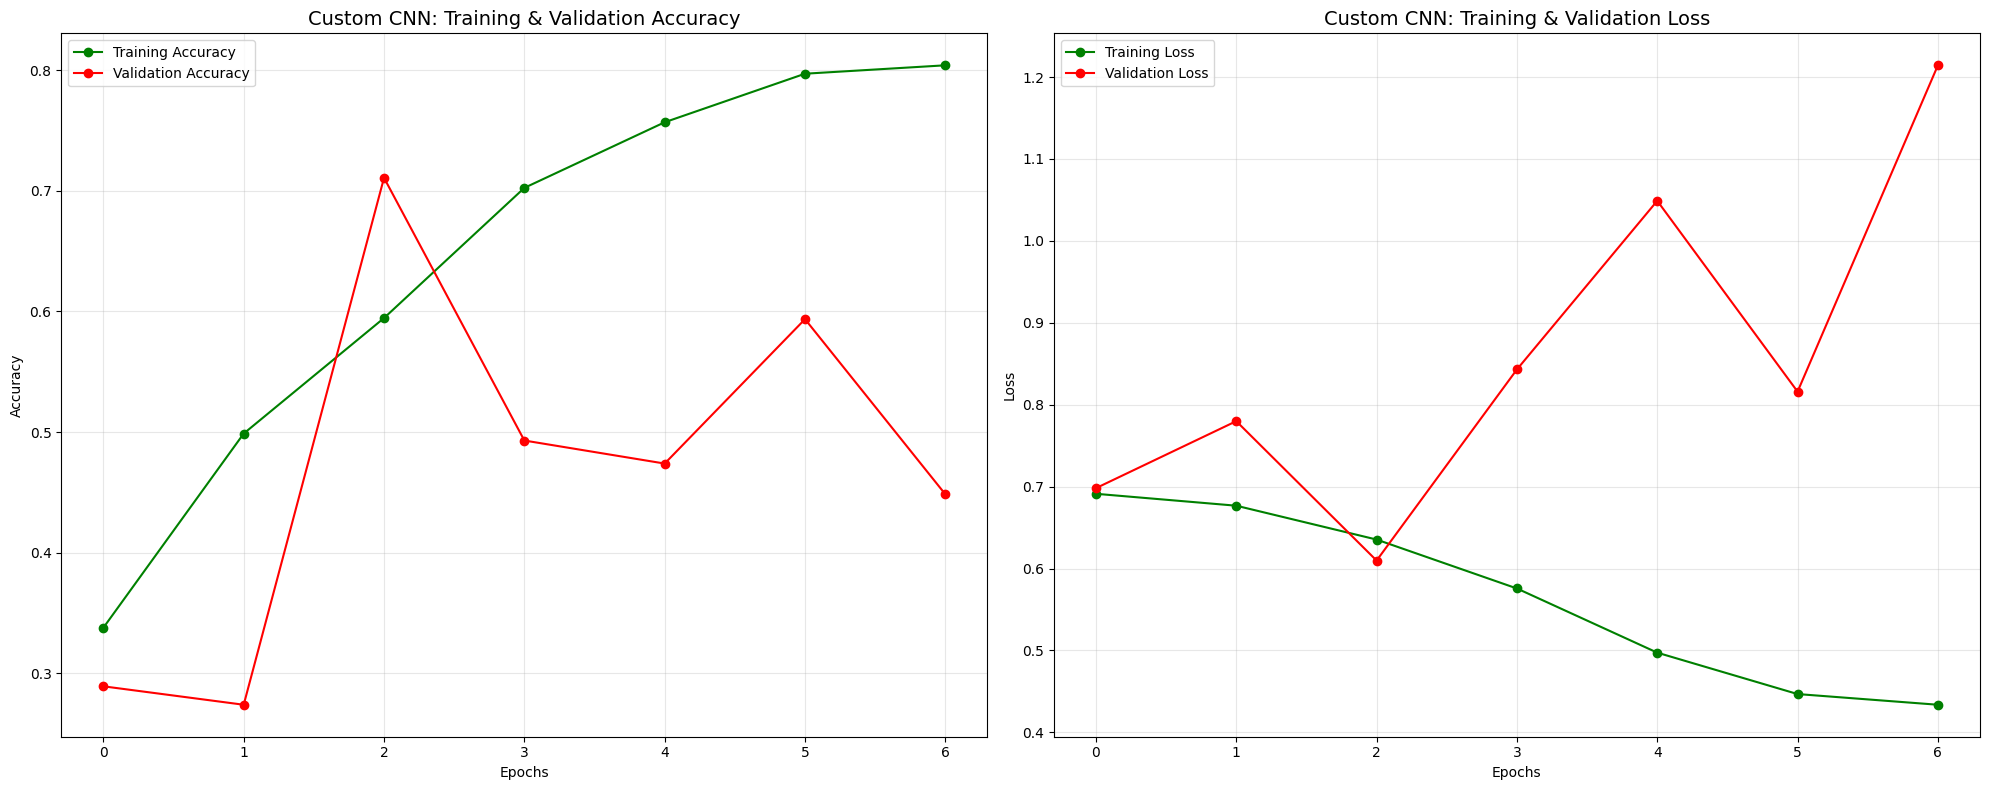

Training model: MobileNetV2
Epoch 1/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.7445 - loss: 0.5384 - val_accuracy: 0.8955 - val_loss: 0.2616 - learning_rate: 1.0000e-04
Epoch 2/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.8469 - loss: 0.3565 - val_accuracy: 0.9197 - val_loss: 0.2059 - learning_rate: 1.0000e-04
Epoch 3/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.8727 - loss: 0.2959 - val_accuracy: 0.9019 - val_loss: 0.2501 - learning_rate: 1.0000e-04
Epoch 4/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.8916 - loss: 0.2639 - val_accuracy: 0.9108 - val_loss: 0.2260 - learning_rate: 1.0000e-04
Epoch 5/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.8932 - loss: 0.2576 - val_accuracy: 0.9146 - val_loss: 0.2023 - learning_rate: 3.0000e-05
Epoch 6/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.8923 - loss: 0.2627 - val_accuracy: 0.9159 - val_loss: 0.2080 - learning_rate: 3.0000e-05
Epoch 7/12
139/139

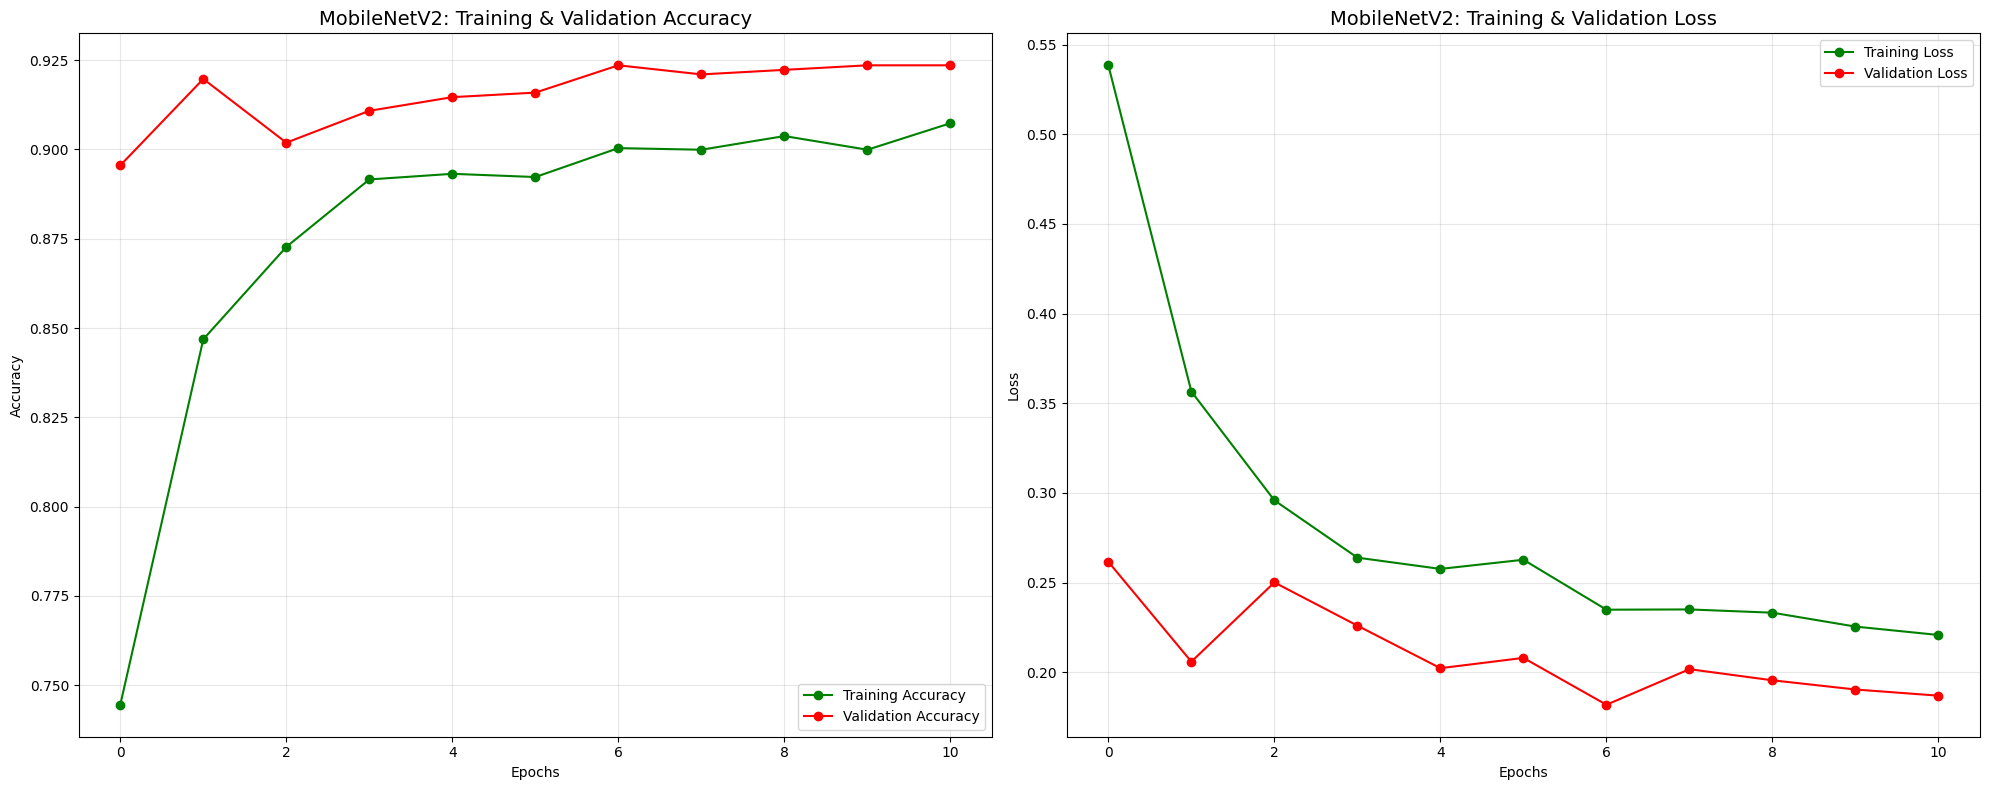

Training model: DenseNet121
Epoch 1/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 151ms/step - accuracy: 0.6688 - loss: 0.7379 - val_accuracy: 0.8306 - val_loss: 0.4110 - learning_rate: 1.0000e-04
Epoch 2/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.8082 - loss: 0.4373 - val_accuracy: 0.8752 - val_loss: 0.3110 - learning_rate: 1.0000e-04
Epoch 3/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.8466 - loss: 0.3546 - val_accuracy: 0.8943 - val_loss: 0.2583 - learning_rate: 1.0000e-04
Epoch 4/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.8658 - loss: 0.3156 - val_accuracy: 0.8777 - val_loss: 0.3107 - learning_rate: 1.0000e-04
Epoch 5/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.8660 - loss: 0.3088 - val_accuracy: 0.8968 - val_loss: 0.2493 - learning_rate: 1.0000e-04
Epoch 6/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - accuracy: 0.8878 - loss: 0.2676 - val_accuracy: 0.8943 - val_loss: 0.2791 - learning_rate: 1.0000e-04
Epoch 7/12
139/139

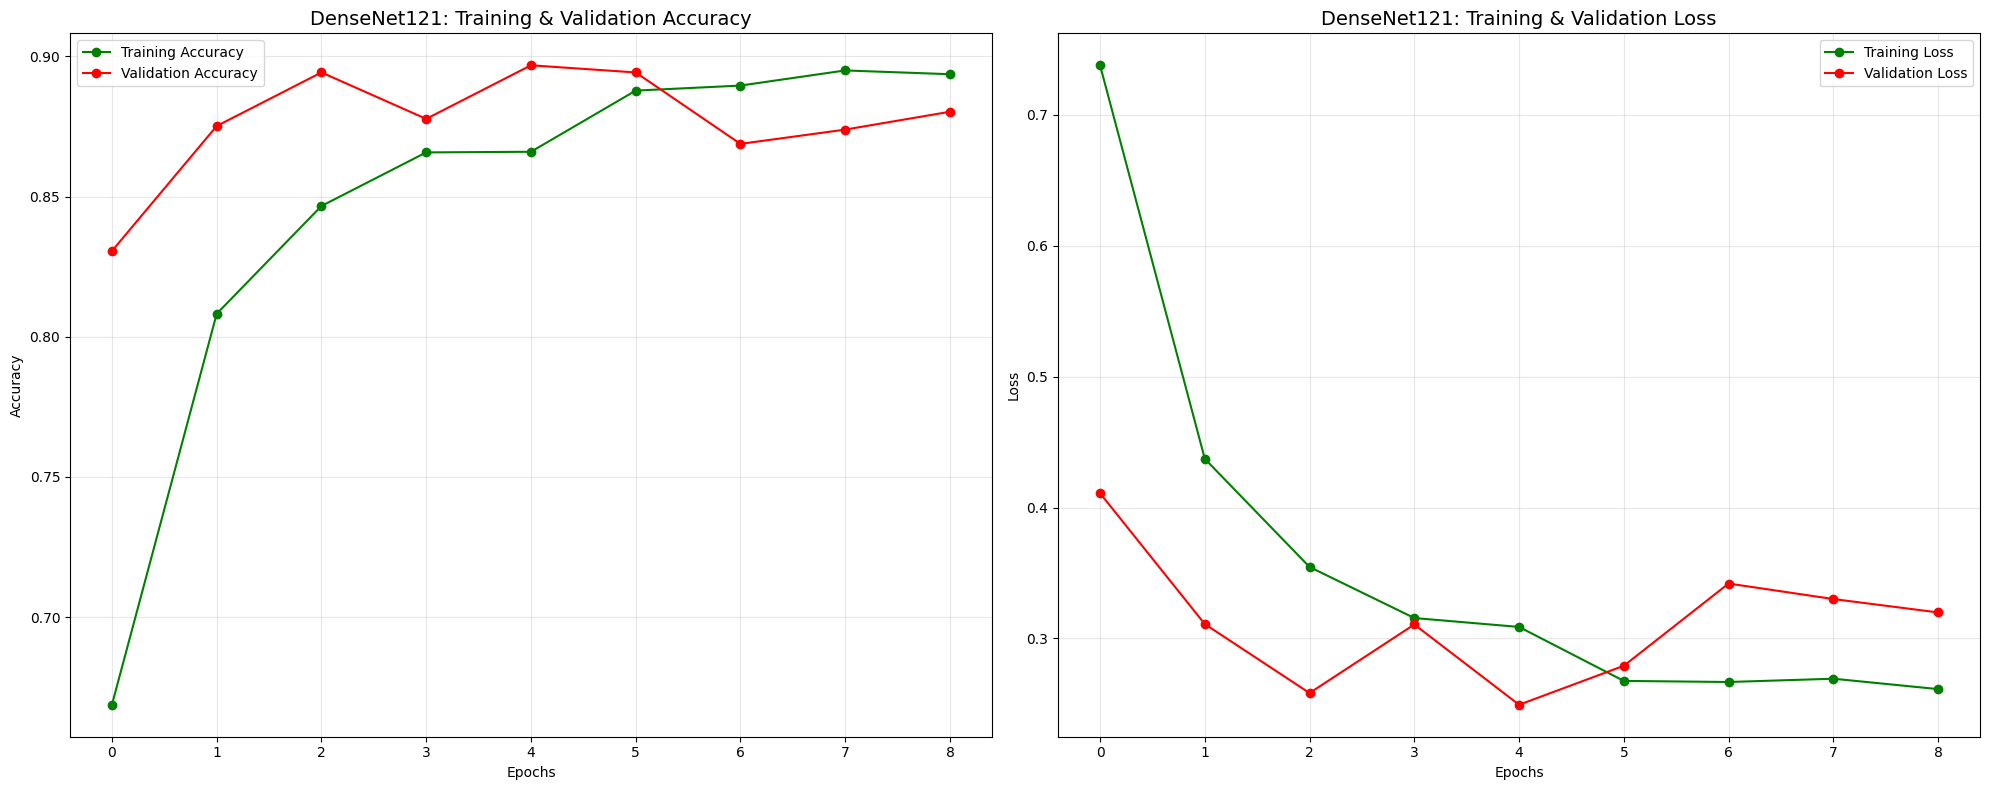

In [18]:
# Store models and histories in dictionaries for easy comparison later.
trained_models = {
    "Custom CNN": custom_cnn,
    "MobileNetV2": mobile_net,
    "DenseNet121": dense_net
}

histories = {}

# Train each model one by one.
for model_name, model in trained_models.items():
    histories[model_name] = compile_and_train_model(model, model_name)

## 19. Evaluation Function

**What we do in this cell:**

We create a function that evaluates any trained model on the test set.

It calculates:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

**Why this is important:**

In medical image classification, accuracy alone is not enough. Recall is especially important because missing pneumonia cases can be serious.

In [19]:
def evaluate_model(model, model_name):
    """Evaluate a trained model on the test dataset."""
    # Predict pneumonia probability for every test image.
    probabilities = model.predict(test_ds, verbose=0).reshape(-1)

    # Convert probabilities into class predictions using the selected threshold.
    y_pred = (probabilities >= THRESHOLD).astype(int)

    # Convert true labels to numpy array.
    y_true = np.array(test_labels).astype(int)

    # Calculate metrics.
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    # Create a dictionary of results.
    result = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Confusion Matrix": cm,
        "Probabilities": probabilities,
        "Predictions": y_pred,
        "True Labels": y_true
    }

    return result

## 20. Evaluate All Models

**What we do in this cell:**

We evaluate the three models on the same test set.

**Why this is important:**

The test set is not used during training. It gives a more honest estimate of model performance.

Custom CNN
              precision    recall  f1-score   support

      NORMAL       0.52      0.76      0.62       234
   PNEUMONIA       0.80      0.59      0.68       390

    accuracy                           0.65       624
   macro avg       0.66      0.67      0.65       624
weighted avg       0.70      0.65      0.66       624



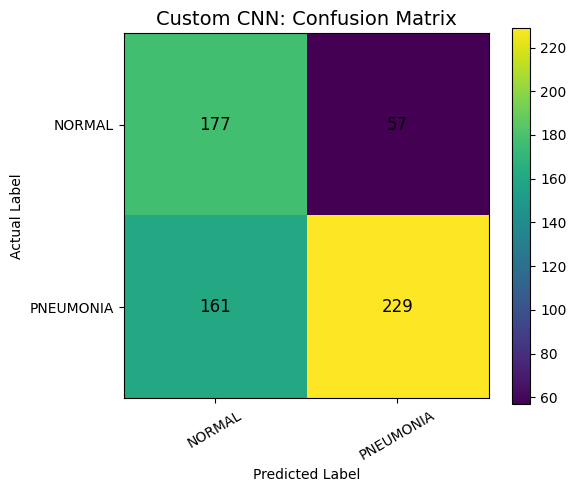

MobileNetV2
              precision    recall  f1-score   support

      NORMAL       0.92      0.57      0.70       234
   PNEUMONIA       0.79      0.97      0.87       390

    accuracy                           0.82       624
   macro avg       0.85      0.77      0.79       624
weighted avg       0.84      0.82      0.81       624



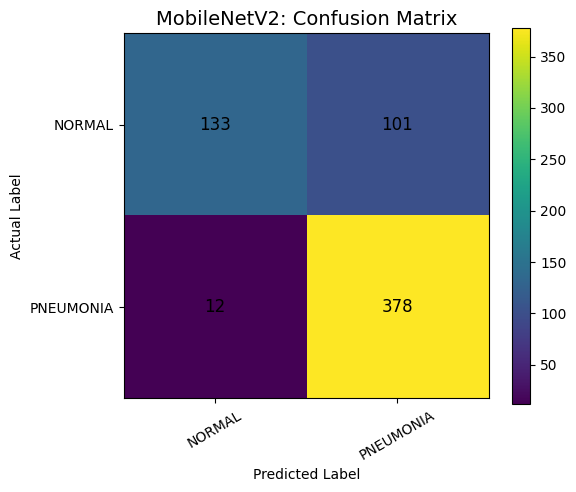

DenseNet121
              precision    recall  f1-score   support

      NORMAL       0.85      0.79      0.82       234
   PNEUMONIA       0.88      0.92      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.86      0.86       624
weighted avg       0.87      0.87      0.87       624



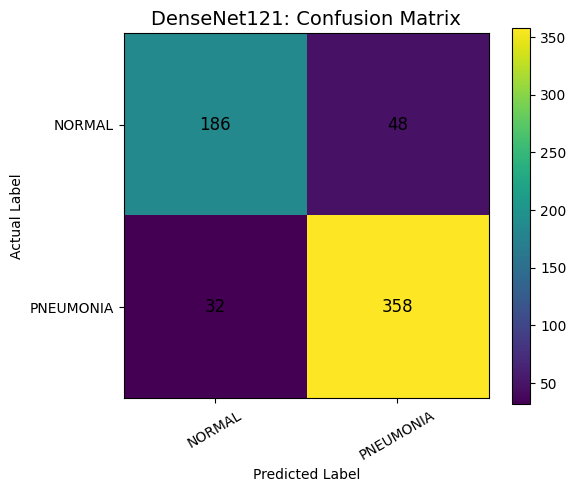

In [20]:
# Evaluate each model and store results.
evaluation_results = []

for model_name, model in trained_models.items():
    result = evaluate_model(model, model_name)
    evaluation_results.append(result)

    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(classification_report(
        result["True Labels"],
        result["Predictions"],
        target_names=class_names,
        zero_division=0
    ))

    plot_confusion_matrix(result["Confusion Matrix"], model_name)

## 21. Final Comparison Table

**What we do in this cell:**

We create a clean table comparing all models.

**Why this is important:**

This table is one of the most important outputs for the graduation report and poster.

In [21]:
# Convert evaluation results into a clean DataFrame.
comparison_rows = []

for result in evaluation_results:
    comparison_rows.append({
        "Model": result["Model"],
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1-score": result["F1-score"]
    })

comparison_df = pd.DataFrame(comparison_rows)

# Round values for cleaner display.
comparison_df_rounded = comparison_df.copy()
for column in ["Accuracy", "Precision", "Recall", "F1-score"]:
    comparison_df_rounded[column] = comparison_df_rounded[column].round(4)

# Save the comparison table.
comparison_csv_path = OUTPUT_DIR / "model_comparison_results.csv"
comparison_df_rounded.to_csv(comparison_csv_path, index=False)

print("Comparison table saved to:", comparison_csv_path)
comparison_df_rounded

Comparison table saved to: /kaggle/working/model_comparison_results.csv


,Model,Accuracy,Precision,Recall,F1-score
0,Custom CNN,0.6506,0.8007,0.5872,0.6775
1,MobileNetV2,0.8189,0.7891,0.9692,0.8700
2,DenseNet121,0.8718,0.8818,0.9179,0.8995


## 22. Final Comparison Plot

**What we do in this cell:**

We visualize the comparison table as a grouped bar chart.

**Why this is important:**

A plot is easier to understand quickly than numbers alone. This figure can be used in the final presentation or poster.

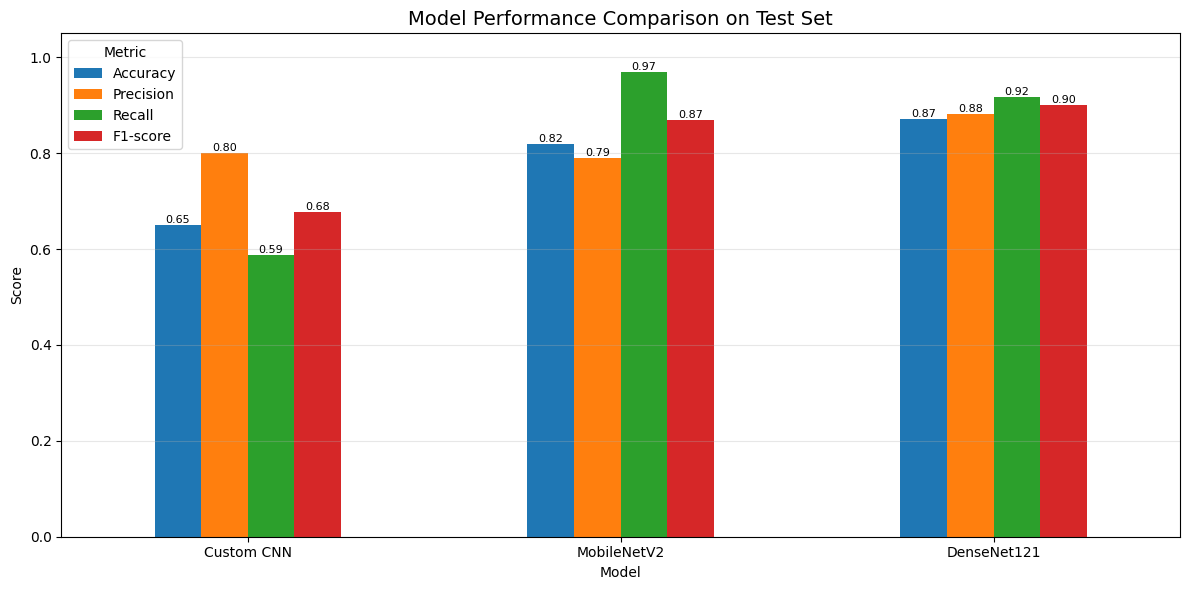

In [22]:
# Prepare the comparison plot.
plot_df = comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]]

# Draw the grouped bar chart.
ax = plot_df.plot(kind="bar", figsize=(12, 6), rot=0)

# Add title and labels.
plt.title("Model Performance Comparison on Test Set", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

# Add values on top of bars.
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)

plt.tight_layout()
plt.show()

## 23. Select the Best Model

**What we do in this cell:**

We select the best model using the F1-score.

**Why F1-score?**

F1-score balances precision and recall. This is useful when the dataset is imbalanced.

In [23]:
# Select best model based on F1-score.
best_row = comparison_df.sort_values(by="F1-score", ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print(best_row)

Best model: DenseNet121
Model        DenseNet121
Accuracy        0.871795
Precision       0.881773
Recall          0.917949
F1-score        0.899497
Name: 2, dtype: object


## 24. Show Incorrect Predictions for the Best Model

**What we do in this cell:**

We show a small grid of incorrectly classified X-ray images.

**Why this is important:**

Incorrect predictions help us understand where the model struggles. This is useful for discussion in the final report.

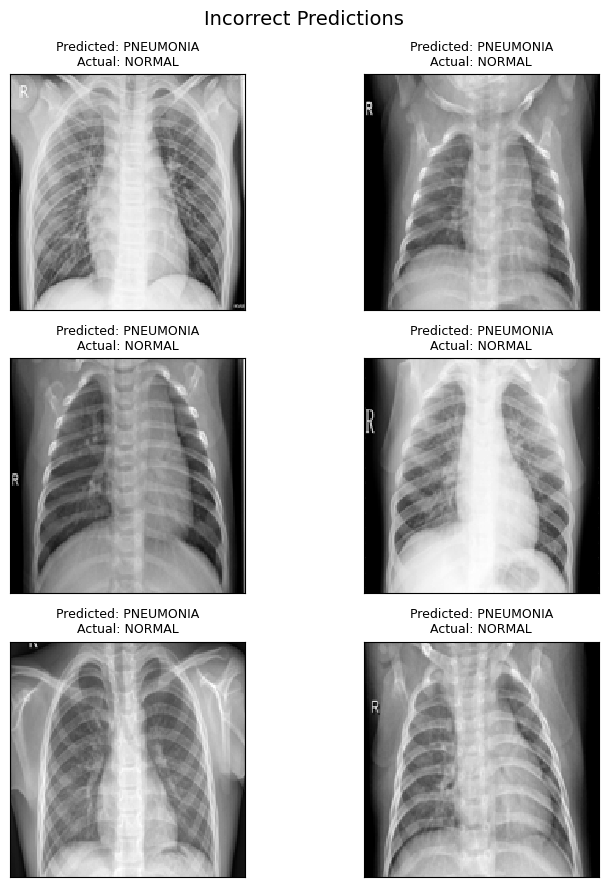

In [24]:
# Find stored evaluation result for the best model.
best_result = next(result for result in evaluation_results if result["Model"] == best_model_name)

# Display the first six incorrect predictions in a small grid.
plot_incorrect_predictions(
    image_paths=test_paths,
    y_true=best_result["True Labels"],
    y_pred=best_result["Predictions"],
    max_images=6
)

## 25. Test One Image Manually

**What we do in this cell:**

We test the best model on one image and display the prediction.

**Why this is important:**

This makes the notebook feel like a real application, not only a training experiment.

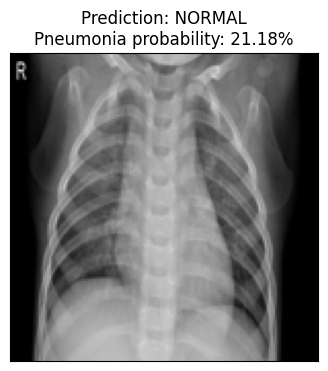

In [25]:
def predict_single_image(model, image_path):
    """Predict one image using the trained model."""
    # Load image and resize it.
    image = Image.open(image_path).convert("RGB").resize(IMG_SIZE)

    # Convert image to array.
    image_array = np.array(image).astype("float32")

    # Add batch dimension because the model expects a batch of images.
    image_batch = np.expand_dims(image_array, axis=0)

    # Predict probability.
    probability = float(model.predict(image_batch, verbose=0)[0][0])

    # Convert probability to class.
    predicted_label = 1 if probability >= THRESHOLD else 0
    predicted_class = label_to_class[predicted_label]

    return image, probability, predicted_class


# Select the first test image as an example.
example_image_path = test_paths[0]
example_image, probability, predicted_class = predict_single_image(best_model, example_image_path)

# Display the image and prediction.
plt.figure(figsize=(4, 4))
plt.imshow(example_image, cmap="gray")
plt.xticks([])
plt.yticks([])
plt.title(f"Prediction: {predicted_class}\nPneumonia probability: {probability:.2%}")
plt.show()

## 26. Save the Best Model and Project Metadata

**What we do in this cell:**

We save:
- The best trained model.
- The class names.
- The comparison results.

**Why this is important:**

The saved model will be used later in the web application.

In [26]:
# Save the best model in Keras format.
best_model_path = OUTPUT_DIR / "best_pneumonia_model.keras"
best_model.save(best_model_path)

# Save class names for the web application.
class_names_path = OUTPUT_DIR / "class_names.json"
with open(class_names_path, "w") as file:
    json.dump(class_names, file)

# Save best model name.
metadata_path = OUTPUT_DIR / "project_metadata.json"
with open(metadata_path, "w") as file:
    json.dump(
        {
            "best_model_name": best_model_name,
            "image_size": IMG_SIZE,
            "threshold": THRESHOLD,
            "class_names": class_names
        },
        file,
        indent=4
    )

print("Best model saved to:", best_model_path)
print("Class names saved to:", class_names_path)
print("Metadata saved to:", metadata_path)

Best model saved to: /kaggle/working/best_pneumonia_model.keras
Class names saved to: /kaggle/working/class_names.json
Metadata saved to: /kaggle/working/project_metadata.json


## 27. Create a Simple Streamlit Web Application

**What we do in this cell:**

We generate a basic `streamlit_app.py` file.

**Why this is important:**

This is the first step toward converting the notebook into a real web application where users can upload a chest X-ray image and get a prediction.

In [27]:
streamlit_code = r"""
import json
import numpy as np
import streamlit as st
from PIL import Image
import tensorflow as tf

st.set_page_config(page_title="Pneumonia Detection", page_icon="🫁", layout="centered")

st.title("Pneumonia Detection from Chest X-Ray Images")
st.write("Upload a chest X-ray image and the trained model will predict whether it is Normal or Pneumonia.")
st.warning("This application is for educational purposes only and must not be used as a medical diagnosis tool.")

MODEL_PATH = "best_pneumonia_model.keras"
CLASS_NAMES_PATH = "class_names.json"
IMG_SIZE = (150, 150)
THRESHOLD = 0.50

@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)

@st.cache_data
def load_class_names():
    with open(CLASS_NAMES_PATH, "r") as file:
        return json.load(file)

model = load_model()
class_names = load_class_names()

uploaded_file = st.file_uploader("Upload a chest X-ray image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded X-Ray Image", use_container_width=True)

    resized_image = image.resize(IMG_SIZE)
    image_array = np.array(resized_image).astype("float32")
    image_batch = np.expand_dims(image_array, axis=0)

    probability = float(model.predict(image_batch, verbose=0)[0][0])
    predicted_label = 1 if probability >= THRESHOLD else 0
    predicted_class = class_names[predicted_label]

    st.subheader("Prediction Result")
    st.write(f"**Predicted class:** {predicted_class}")
    st.write(f"**Pneumonia probability:** {probability:.2%}")

    st.progress(probability)
"""

# Write the Streamlit app file.
app_path = OUTPUT_DIR / "streamlit_app.py"
with open(app_path, "w") as file:
    file.write(streamlit_code)

# Write a small requirements file.
requirements_path = OUTPUT_DIR / "requirements.txt"
with open(requirements_path, "w") as file:
    file.write("streamlit\ntensorflow\npillow\nnumpy\n")

print("Streamlit app saved to:", app_path)
print("Requirements file saved to:", requirements_path)

Streamlit app saved to: /kaggle/working/streamlit_app.py
Requirements file saved to: /kaggle/working/requirements.txt


## 28. Final Project Summary

### What was done

This notebook implemented a complete pneumonia detection project using chest X-ray images. It compared three deep learning models:

| Model | Purpose |
|---|---|
| Custom CNN | Baseline model built from scratch |
| MobileNetV2 | Lightweight transfer learning model |
| DenseNet121 | Strong transfer learning model for image classification |

### Why this is strong?

This version includes:

- Automatic Kaggle dataset path detection.
- Clean dataset analysis and class distribution.
- Fair train/validation/test split.
- Data augmentation.
- Three-model comparison.
- Accuracy, precision, recall, and F1-score.
- Confusion matrices.
- Incorrect prediction visualization.
- Best model selection.
- Saved model for deployment.
- Starter Streamlit web application.

In [29]:
# Save the best model in Keras format.
best_model_path = OUTPUT_DIR / "best_pneumonia_model.keras"
best_model.save(best_model_path)

# Save class names for the web application.
class_names_path = OUTPUT_DIR / "class_names.json"
with open(class_names_path, "w") as file:
    json.dump(class_names, file)

# Save best model metadata.
metadata_path = OUTPUT_DIR / "project_metadata.json"
with open(metadata_path, "w") as file:
    json.dump(
        {
            "best_model_name": best_model_name,
            "image_size": IMG_SIZE,
            "threshold": THRESHOLD,
            "class_names": class_names
        },
        file,
        indent=4
    )

print("Best model saved to:", best_model_path)

Best model saved to: /kaggle/working/best_pneumonia_model.keras


In [30]:
app_code = """
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

MODEL_PATH = "best_pneumonia_model.keras"
IMG_SIZE = (150, 150)

st.set_page_config(
    page_title="Pneumonia Detection App",
    page_icon="🫁",
    layout="centered"
)

st.title("🫁 Pneumonia Detection from Chest X-Ray Images")
st.write("Upload a chest X-ray image and the model will predict Normal or Pneumonia.")

st.warning("Educational demo only. This app is not a real medical diagnosis system.")

@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)

model = load_model()

uploaded_file = st.file_uploader(
    "Upload chest X-ray image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    st.image(image, caption="Uploaded X-Ray Image", use_container_width=True)

    img = image.resize(IMG_SIZE)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    probability = model.predict(img_array)[0][0]

    if probability >= 0.5:
        prediction = "PNEUMONIA"
        confidence = probability
        st.error(f"Prediction: {prediction}")
    else:
        prediction = "NORMAL"
        confidence = 1 - probability
        st.success(f"Prediction: {prediction}")

    st.write(f"Confidence: {confidence * 100:.2f}%")
    st.progress(float(confidence))

    st.write("---")
    st.write("Model used: DenseNet121")
    st.write("Image size: 150 x 150")
"""

with open("streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Streamlit app created: streamlit_app.py")

Streamlit app created: streamlit_app.py
